# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Fanidyasani Atantya Winayaka Purba
- **Email:** faniatantya@gmail.com
- **ID Dicoding:** fanidyasaniatantya

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana performa pendapatan (revenue) dari berbagai kategori produk selama periode tahun 2018, dan kategori mana yang memberikan kontribusi paling signifikan?
- Pertanyaan 2: Bagaimana segmentasi profil pelanggan berdasarkan perilaku belanja menggunakan metode analisis RFM pada periode tahun 2018 untuk merancang strategi pemasaran yang lebih personal?
- Pertanyaan 3: Bagaimana tren performa penjualan perusahaan dari bulan ke bulan selama tahun 2018?

## Import Semua Packages/Library yang Digunakan

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
sns.set_style("whitegrid")
from scipy.stats import skew, kurtosis

## Data Wrangling

### Gathering Data

In [173]:
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [174]:
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [175]:
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [176]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [177]:
product_category_df = pd.read_csv("product_category_name_translation.csv")
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset orders dan order_items: Kedua dataset ini merupakan fondasi utama untuk menjawab Pertanyaan 1 dan 3. Kolom order_purchase_timestamp sangat krusial; selain untuk memfilter data khusus tahun 2018 (P1), kolom ini digunakan untuk melakukan ekstraksi tren bulanan guna melihat pola fluktuasi pendapatan sepanjang tahun (Pertanyaan 3). Selain itu, filter pada order_status ("delivered") diterapkan untuk memastikan validitas angka revenue, sementara kolom price pada order_items digunakan sebagai metrik utama penghitungan pendapatan murni.
- Dataset customers: Dataset ini adalah kunci untuk menjawab Pertanyaan 2 (Analisis RFM). Pelanggan dapat memiliki beberapa customer_id yang berbeda untuk setiap transaksi, namun hanya memiliki satu customer_unique_id. Penggunaan ID unik ini bersifat wajib dalam analisis Frequency, karena jika salah menggunakan ID, sistem akan gagal mengidentifikasi perilaku belanja berulang dari pelanggan yang sama, sehingga profil loyalitas tidak akan akurat.
- Dataset products dan product_category_name_translation: Dataset products memerlukan tabel translasi untuk mengubah kategori produk dari bahasa Portugis ke bahasa Inggris agar hasil visualisasi pada dashboard nantinya lebih informatif dan mudah dipahami oleh pengguna luas.

### Assessing Data

In [178]:
print("\nInfo orders_df:")
print(orders_df.info())
print("\nDescribe orders_df:")
print(orders_df.describe())
print("\nMissing values di orders_df:")
print(orders_df.isna().sum())
print("\nJumlah duplikasi:", orders_df.duplicated().sum())


Info orders_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Describe orders_df:
                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                       

In [179]:
print("\nInfo order_items_df:")
print(order_items_df.info())
print("\nDescribe order_items_df:")
print(order_items_df.describe())
print("\nMissing values di order_items_df:")
print(order_items_df.isna().sum())
print("\nJumlah duplikasi:", order_items_df.duplicated().sum())


Info order_items_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None

Describe order_items_df:
       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%       

In [180]:
print("\nInfo products_df:")
print(products_df.info())
print("\nDescribe products_df:")
print(products_df.describe())
print("\nMissing values di products_df:")
print(products_df.isna().sum())
print("\nJumlah duplikasi:", products_df.duplicated().sum())


Info products_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None

Describe products_df:
       product_name_lenght  product_description_lenght  product_photos_qty  \
count         32341.000000                32341.000000        32341.000000   
mean      

In [181]:
print("\nInfo customers_df:")
print(customers_df.info())
print("\nDescribe customers_df:")
print(customers_df.describe())
print("\nMissing values di customers_df:", customers_df.isna().sum())
print("\nJumlah duplikasi:", customers_df.duplicated().sum())


Info customers_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Describe customers_df:
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

Missing values di customers_df: customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
cust

In [182]:
print("\nInfo product_category_df:")
print(product_category_df.info())
print("\nDescribe product_category_df:")
print(product_category_df.describe())
print("\nMissing values di product_category_df:")
print(product_category_df.isna().sum())
print("\nJumlah duplikasi:", product_category_df.duplicated().sum())


Info product_category_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None

Describe product_category_df:
       product_category_name product_category_name_english
count                     71                            71
unique                    71                            71
top             beleza_saude                 health_beauty
freq                       1                             1

Missing values di product_category_df:
product_category_name            0
product_category_name_english    0
dtype: int64

Jumlah duplikasi: 0


**Insight:**
- Seluruh data yang diperlukan tidak memiliki duplikasi data
- Tipe Data Salah: Semua kolom tanggal di orders_df terdeteksi sebagai object (string). Ini harus diubah ke datetime agar kita bisa memfilter tahun 2018 dan menghitung Recency untuk RFM.
- Missing Values di orders_df: Kolom order_delivered_customer_date memiliki 2.965 data kosong. Dalam bisnis e-commerce, tidak semua pesanan berakhir sukses sampai di tangan pelanggan. Ada pesanan yang masih dalam perjalanan (shipped), masih diproses (processing), atau bahkan dibatalkan (canceled). Jika pesanan belum sampai, maka kolom "tanggal diterima pelanggan" pasti kosong. Ini adalah informasi penting untuk validasi. Dalam menghitung Revenue, biasanya hanya menghitung pesanan yang statusnya sudah 'delivered'. Data kosong ini membantu dalam memisahkan mana transaksi yang sudah sah jadi pendapatan dan mana yang masih menggantung.
- Missing Values di products_df: Terdapat 610 baris di mana kolom product_category_name bernilai NaN (kosong). Ini merupakan masalah, karena ketika menggabungkan tabel transaksi (order_items) dengan tabel produk (products), pesanan yang berisi produk-produk tanpa kategori ini akan tetap muncul, tetapi kolom kategorinya akan kosong.
- Missing Values di customers_df: Pengecekan customers_df menunjukkan angka 0 untuk semua kolom, sehingga data profil pelanggan sudah sangat bersih.

### Cleaning Data

Cleaning Data orders_df

In [183]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Cek kembali tipe data
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


Cleaning Data products_df

In [184]:
products_df.dropna(axis=0, inplace=True)

print("Jumlah missing values setelah cleaning:")
print(products_df.isna().sum())

Jumlah missing values setelah cleaning:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Insight:**
- Transformasi Tipe Data: Kolom-kolom yang berkaitan dengan waktu (seperti order_purchase_timestamp dan lainnya) telah berhasil dikonversi menjadi tipe data datetime. Hal ini sangat krusial agar kita dapat melakukan ekstraksi komponen waktu (bulan/tahun) untuk Analisis Tren Penjualan (Pertanyaan 3), melakukan filtering data tahun 2018 (Pertanyaan 1), serta menghitung selisih hari untuk metrik Recency pada analisis RFM (Pertanyaan 2).
- Penanganan Missing Values: Pada kolom product_category_name, nilai yang hilang (NaN) diisi dengan string 'unknown' untuk menjaga integritas data. Jika baris tersebut dihapus, maka total revenue yang dihitung nantinya akan lebih kecil dari nilai aslinya.
- Konsolidasi Data (Merging): Seluruh tabel kunci (Orders, Order Items, Products, Customers, dan Product Category Translation) telah diintegrasikan ke dalam satu DataFrame utama bernama main_df.
- Integrasi Data: Seluruh tabel yang relevan telah digabungkan ke dalam satu DataFrame tunggal bernama main_df. DataFrame ini sekarang mengandung informasi harga, kategori produk, waktu transaksi, dan identitas unik pelanggan secara lengkap.

## Exploratory Data Analysis (EDA)

### Explore orders_df

In [185]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
78941,d2f3c6bc866e8739ed6b470f1c13cc44,d82827f717f9c28668c81a103047726a,delivered,2017-04-26 12:56:58,2017-04-27 13:25:26,2017-04-28 13:17:45,2017-05-11 09:59:49,2017-05-29
97196,8dca7901c45e1525ad654814a7db9eea,043e1a8a42664d4e6fd092d4b1f878e7,delivered,2018-01-05 01:35:24,2018-01-05 01:47:53,2018-01-05 22:58:11,2018-01-08 19:55:23,2018-01-23
32732,b68bc5e23953ce5d6eb6fd2fc3055763,8901c3b17ec32af7630fe1d96955db36,delivered,2017-08-24 15:22:24,2017-08-24 15:35:15,2017-08-25 15:53:49,2017-09-06 11:39:57,2017-09-28
42063,47c3922747c2990080644decd9ab23c4,e8e957a7fcefa603bbdca0f5a33db8e5,delivered,2018-01-21 14:07:05,2018-01-22 13:50:42,2018-01-23 19:32:13,2018-02-01 11:07:13,2018-02-19
54247,d27a1b863a5393c76d910b9563093adc,5fb6c217fa89e61c033f8499bbad0140,delivered,2018-03-07 14:44:23,2018-03-07 15:09:58,2018-03-09 16:19:32,2018-03-14 23:37:32,2018-03-23


In [186]:
print("Statistik Deskriptif orders_df:")
display(orders_df.describe(include="all"))

Statistik Deskriptif orders_df:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [187]:
print("\nDistribusi Status Pesanan:")
order_status_counts = orders_df.order_status.value_counts()
display(order_status_counts)


Distribusi Status Pesanan:


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [188]:
delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds() / 86400)
orders_df["delivery_time"] = delivery_time

delivery_error = orders_df["order_estimated_delivery_date"] - orders_df["order_delivered_customer_date"]
delivery_error = delivery_error.apply(lambda x: x.total_seconds() / 86400)
orders_df["delivery_error"] = delivery_error

print("\nStatistik Waktu Pengiriman (Hari):")
display(orders_df[["delivery_time", "delivery_error"]].describe())

print("Jumlah data delivery_time tidak masuk akal:", orders_df[orders_df["delivery_time"] < 0].shape[0])

print("Jumlah pesanan yang terlambat:", orders_df[orders_df["delivery_error"] < 0].shape[0])

orders_df = orders_df[orders_df["delivery_time"] >= 0]


Statistik Waktu Pengiriman (Hari):


,delivery_time,delivery_error
count,96476.000000,96476.000000
mean,12.558702,11.179120
std,9.546530,10.186113
min,0.533414,-188.975081
25%,6.766403,6.390000
50%,10.217755,11.948941
75%,15.720327,16.244384
max,209.628611,146.016123


Jumlah data delivery_time tidak masuk akal: 0
Jumlah pesanan yang terlambat: 7827


In [189]:
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

print("Tren Jumlah Pesanan Per Bulan:")
display(orders_df.groupby('order_month').order_id.nunique())

Tren Jumlah Pesanan Per Bulan:


,order_id
order_month,
2016-09,1
2016-10,270
2016-12,1
2017-01,750
2017-02,1653
2017-03,2546
2017-04,2303
2017-05,3545
2017-06,3135


In [190]:
# 1. Mengeksplorasi jam berapa pelanggan paling banyak melakukan pemesanan
orders_df['order_hour'] = orders_df['order_purchase_timestamp'].dt.hour
print("Distribusi Pesanan Berdasarkan Jam:")
display(orders_df.groupby(by="order_hour").order_id.nunique().sort_values(ascending=False))

# 2. Mengeksplorasi hari apa dalam seminggu pelanggan paling banyak belanja
orders_df['order_day'] = orders_df['order_purchase_timestamp'].dt.day_name()
print("\nDistribusi Pesanan Berdasarkan Hari:")
display(orders_df.groupby(by="order_day").order_id.nunique().sort_values(ascending=False))

Distribusi Pesanan Berdasarkan Jam:


,order_id
order_hour,
16,6475
11,6385
14,6384
13,6309
15,6250
21,6040
20,6008
10,5978
17,5961



Distribusi Pesanan Berdasarkan Hari:


,order_id
order_day,
Monday,15703
Tuesday,15502
Wednesday,15074
Thursday,14322
Friday,13685
Sunday,11634
Saturday,10556


**Insight:**
- Status Operasional Pesanan
  - Mayoritas pesanan dalam dataset memiliki status delivered (sebanyak 96478).
  - Adanya sejumlah kecil pesanan dengan status canceled (625) atau unavailable (609).
- Efisiensi Pengiriman (Logistik)
  - Pelanggan rata-rata menerima pesanan dalam waktu 12,56 hari setelah pembelian.
  - Analisis pada delivery_error menunjukkan bahwa Rata-rata pesanan tiba 11,18 hari lebih awal dari estimasi yang diberikan perusahaan. Namun, terdapat 7.827 pesanan yang terlambat (di mana delivery_error bernilai negatif), dengan keterlambatan ekstrem mencapai 188,97 hari dari tanggal yang dijanjikan.
  - Ditemukan 1 baris data dengan delivery_time negatif (barang sampai sebelum dibeli).
  - Terdapat kontras yang ekstrem, di mana pengiriman tercepat dilakukan dalam 0,53 hari (sekitar 12 jam), namun pengiriman terlama mencapai 209,63 hari.
- Tren Penjualan dan Musiman
  - Bulan November 2017 merupakan periode dengan jumlah pesanan tertinggi (7.544 order).
  - Keterbatasan Data: Data pada September 2016 dan Desember 2016)terlihat tidak lengkap karena hanya mencatat 1 pesanan

- Waktu Ramai
  - Jam Paling Sibuk (Peak Hour): Aktivitas belanja mencapai puncaknya pada pukul 16:00 (jam 4 sore) dengan total 6.475 pesanan. Secara umum, jam produktif (10:00 - 16:00) merupakan periode dengan volume transaksi tertinggi.
  - Hari Paling Sibuk (Peak Day): Senin adalah hari favorit pelanggan untuk berbelanja dengan total 15.703 pesanan.

### Explore customers_df

In [191]:
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
81749,f6875989fac1fae11faf6e9437ee905f,eb76bff7e52231f6e8a9b97b14f3f2bd,95905,lajeado,RS
88919,3bb38d7e15146509176acff3db811f13,215ea7f5a1601fcf949dfe01cfd0f3a0,4883,sao paulo,SP
8353,cd07153a3e03b42c948bafeec3ff9b76,f911728544b289f40fd54eb9ea883c17,7054,guarulhos,SP
1817,b6363f9f8f6d461980e9b5a6fbd0e168,57378b07a6c91c06c139bfff05a246ab,3813,sao paulo,SP
8003,88bff74a663c907ffa8fba47dc1cdf28,0651e691ed9e201bf2ce26d40f93d739,18460,itarare,SP


In [192]:
print("Statistik Deskriptif customers_df:")
display(customers_df.describe(include="all"))

Statistik Deskriptif customers_df:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [193]:
print("\nJumlah Pelanggan berdasarkan State:")
customers_by_state = customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)
display(customers_by_state)


Jumlah Pelanggan berdasarkan State:


,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [194]:
print("\nTop 10 Kota dengan Pelanggan Terbanyak:")
customers_by_city = customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10)
display(customers_by_city)


Top 10 Kota dengan Pelanggan Terbanyak:


,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


**Insight:**
- Negara Bagian Terbesar (State): SP (São Paulo) menjadi pusat pelanggan utama dengan jumlah mencapai 41.746 pelanggan. Angka ini sangat jauh melampaui posisi kedua, RJ (Rio de Janeiro), yang memiliki 12.852 pelanggan.
- Dominasi Kota: São Paulo secara spesifik menyumbang 15.540 pelanggan, menjadikannya pasar tunggal terbesar yang hampir mencapai 2,3 kali lipat dari ukuran pasar Rio de Janeiro (6.882 pelanggan).
- Sebaran Nasional: Bisnis ini telah menjangkau 27 negara bagian dan 4.119 kota di seluruh Brasil, menunjukkan penetrasi pasar yang luas meskipun ada ketimpangan volume antar wilayah.

### Explore products_df

In [195]:
products_df.sample(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
6247,20c26b058070cf8c6bbb8c8943eea98c,automotivo,55.0,703.0,6.0,5100.0,47.0,19.0,23.0
8575,3467600ef392560b5ff4e484d3a5ed20,livros_interesse_geral,33.0,153.0,1.0,400.0,30.0,40.0,30.0
26616,cd87373ff7bdd923cfdff3893c9dea64,consoles_games,57.0,294.0,1.0,460.0,19.0,19.0,17.0
20602,bf3024b979e260a941c418cc5771fff2,utilidades_domesticas,50.0,372.0,1.0,800.0,26.0,21.0,21.0
29029,1e89bd6bc4f739a8b303c92d58bf8014,eletrodomesticos,53.0,106.0,2.0,450.0,20.0,13.0,12.0


In [196]:
print("Statistik Deskriptif products_df:")
display(products_df.describe(include="all"))

Statistik Deskriptif products_df:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32340,32340,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000
unique,32340,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476592,771.492393,2.188961,2276.956586,30.854545,16.958813,23.208596
std,NaN,NaN,10.245699,635.124831,1.736787,4279.291845,16.955965,13.636115,12.078762
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [197]:
print("\nKategori yang paling banyak tersedia (Top 10):")
category_counts = products_df.groupby(by="product_category_name").product_id.nunique().sort_values(ascending=False).head(10)
display(category_counts)


Kategori yang paling banyak tersedia (Top 10):


,product_id
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


In [198]:
print("\nRata-rata Berat dan Dimensi Produk:")
display(products_df[['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].mean())


Rata-rata Berat dan Dimensi Produk:


,0
product_weight_g,2276.956586
product_length_cm,30.854545
product_height_cm,16.958813
product_width_cm,23.208596


**Insight:**
- Kategori yang paling banyak tersedia adalah cama_mesa_banho menempati posisi puncak dengan 3.029 produk unik. Diikuti oleh Kategori esporte_lazer (2.867 produk) dan moveis_decoracao (2.657 produk) melengkapi tiga besar, menunjukkan bahwa variasi produk paling banyak tersedia di kategori-kategori ini.
- Berat Produk: Rata-rata berat produk adalah 2.276,47 gram (sekitar 2,2 kg). Namun, terdapat variasi yang sangat ekstrem mulai dari produk yang sangat ringan (0.000 g) hingga yang paling berat mencapai 40,4 kg (40.425 g).
- Dimensi Rata-rata: Produk memiliki rata-rata panjang 30,8 cm, lebar 23,2 cm, dan tinggi 16,9 cm.
- Produk Terbesar: Produk dengan ukuran maksimum memiliki panjang mencapai 105 cm dan lebar hingga 118 cm.
- Jumlah Foto (produk_photos_qty): Rata-rata produk hanya dilengkapi dengan 2 foto. Nilai median menunjukkan angka 1 foto per produk, namun ada produk yang sangat detail dengan 20 foto.
- Panjang Deskripsi (product_description_lenght): Deskripsi produk rata-rata terdiri dari 771 karakter, dengan deskripsi terpendek hanya 4 karakter dan terpanjang mencapai 3.992 karakter.

### Explore order_items_df

In [199]:
order_items_df.sample(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3685,08613505c6d1fa61ec5908afbb99fe84,1,82cfbad6a3bb123bb807f51078765a0f,80e6699fe29150b372a0c8a1ebf7dcc8,2018-02-19 22:40:28,193.90,35.88
59290,871ea4c791e2d977d094700806eef385,1,399656db7a0d49d36300b81120bffeb1,3b15288545f8928d3e65a8f949a28291,2018-03-01 21:55:35,129.99,18.16
57769,8376f6035204b549b6bae5c4a7aa5a44,1,6a7410f88fe57e3fd4e353cfc04e7b31,406822777a0b9eb5c50e442dd4cd3ec5,2017-11-22 19:31:00,55.90,17.64
52176,76b8568803f110a59ece4167463a4a7e,1,44d097d59e8430f88a67517cd0c4f865,6560211a19b47992c3666cc44a7e94c0,2018-05-04 14:30:19,69.00,7.39
46270,691c30273e86d88ab9be2ac45e25d516,1,a87595e0311a6cb55db1cef3c1c0e7a0,6061155addc1e54b4cfb51c1c2a32ad8,2018-08-13 08:50:25,735.00,19.46


In [200]:
order_items_df['total_price'] = order_items_df['price'] + order_items_df['freight_value']

In [201]:
print("Statistik Deskriptif order_items_df:")
display(order_items_df.describe())

Statistik Deskriptif order_items_df:


,order_item_id,price,freight_value,total_price
count,112650.000000,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320,140.644059
std,0.705124,183.633928,15.806405,190.724394
min,1.000000,0.850000,0.000000,6.080000
25%,1.000000,39.900000,13.080000,55.220000
50%,1.000000,74.990000,16.260000,92.320000
75%,1.000000,134.900000,21.150000,157.937500
max,21.000000,6735.000000,409.680000,6929.310000


In [202]:
print("\nTop 5 Transaksi dengan Nilai Tertinggi:")
display(order_items_df.sort_values(by="total_price", ascending=False).head(5))


Top 5 Transaksi dengan Nilai Tertinggi:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.0,194.31,6929.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.0,193.21,6922.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.0,227.66,6726.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.0,151.34,4950.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.0,74.34,4764.34


In [203]:
print("\nRata-rata Harga dan Ongkir:")
print(order_items_df[['price', 'freight_value']].mean())


Rata-rata Harga dan Ongkir:
price            120.653739
freight_value     19.990320
dtype: float64


**Insight:**
- Rata-rata Pengeluaran: Pelanggan rata-rata mengeluarkan total 140,64 per item, yang terdiri dari harga produk senilai 120,65 dan ongkos kirim sebesar 19,99.
- Rentang Harga Ekstrem: Terdapat produk dengan harga sangat rendah yaitu 0,85, sementara transaksi tertinggi mencapai 6.735,00 hanya untuk satu item produk.
- Beban Ongkir: Rata-rata biaya ongkos kirim menyumbang sekitar 14% dari total pengeluaran per item. Namun, pada transaksi maksimum, biaya pengiriman bisa mencapai 409,68.
- Transaksi Tertinggi: Dicatatkan oleh order_id 0812eb902a67711a1cb742b3cdaa65ae dengan total nilai mencapai 6.929,31 setelah ditambah ongkir.
- Produk dengan product_id 489ae2aa008f021502940f251d4cce7f dan 69c590f7ffc7bf8db97190b6cb6ed62e merupakan penyumbang nilai transaksi terbesar.

### Explore all data

In [204]:
# Menggabungkan order_items dengan products
all_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    on="product_id"
)

# Menambahkan translasi nama kategori (Bahasa Inggris)
all_df = pd.merge(
    left=all_df,
    right=product_category_df,
    how="left",
    on="product_category_name"
)

# Menambahkan informasi order (waktu & status)
all_df = pd.merge(
    left=all_df,
    right=orders_df,
    how="left",
    on="order_id"
)

# Menambahkan informasi pelanggan
all_df = pd.merge(
    left=all_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,product_category_name,product_name_lenght,...,order_estimated_delivery_date,delivery_time,delivery_error,order_month,order_hour,order_day,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff,58.0,...,2017-09-29,7.614421,8.011250,2017-09,8.0,Wednesday,871766c5855e863f6eccc05f988b23cb,28013.0,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop,56.0,...,2017-05-15,16.216181,2.330278,2017-04,10.0,Wednesday,eb28e67c4c0b83846050ddfb8a35d051,15775.0,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,moveis_decoracao,59.0,...,2018-02-05,7.948437,13.444954,2018-01,14.0,Sunday,3818d81c6709e39d06b2738a8d3a2474,35661.0,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumaria,42.0,...,2018-08-20,6.147269,5.435660,2018-08,10.0,Wednesday,af861d436cfc08b2c2ddefd0ba074622,12952.0,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,ferramentas_jardim,59.0,...,2017-03-17,25.114352,15.303808,2017-02,13.0,Saturday,64b576fb70d441e8f1b2d7d446e483c5,13226.0,varzea paulista,SP


In [205]:
# Filter data hanya untuk tahun 2018
all_df_2018 = all_df[all_df['order_purchase_timestamp'].dt.year == 2018]

# Menghitung total revenue per kategori produk (English Name)
category_revenue = all_df_2018.groupby("product_category_name_english").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False).reset_index()

category_revenue.rename(columns={"order_id": "order_count", "price": "revenue"}, inplace=True)
display(category_revenue.head(10))

,product_category_name_english,order_count,revenue
0,health_beauty,5306,755754.49
1,watches_gifts,3416,687577.20
2,bed_bath_table,4844,532358.85
3,sports_leisure,3973,517166.26
4,computers_accessories,3971,496158.31
5,housewares,3351,391823.46
6,furniture_decor,3147,381649.57
7,auto,2419,343288.30
8,baby,1627,250615.79
9,cool_stuff,1391,227743.70


In [206]:
# Tren Bulanan Revenue 2018
monthly_trend = all_df_2018.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "price": "sum"
})
display(monthly_trend)

/tmp/ipykernel_5755/3625510494.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = all_df_2018.resample(rule='M', on='order_purchase_timestamp').agg({


,order_id,price
order_purchase_timestamp,,
2018-01-31,7069,924645.00
2018-02-28,6556,826467.12
2018-03-31,7003,953356.25
2018-04-30,6798,973534.09
2018-05-31,6749,977544.69
2018-06-30,6096,855591.97
2018-07-31,6156,867486.47
2018-08-31,6351,838576.64


In [207]:
# Cek frekuensi belanja per pelanggan
customer_behavior = all_df.groupby("customer_unique_id").agg({
    "order_id": "nunique",
    "price": "sum",
    "order_purchase_timestamp": "max"
}).sort_values(by="price", ascending=False)

display(customer_behavior.head())

,order_id,price,order_purchase_timestamp
customer_unique_id,,,
0a0a92112bd4c708ca5fde585afaa872,1,13440.0,2017-09-29 15:24:52
da122df9eeddfedc1dc1f5349a1a690c,2,7388.0,2017-04-01 15:58:41
763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0,2018-07-15 14:49:44
dc4802a71eae9be1dd28f5d788ceb526,1,6735.0,2017-02-12 20:37:36
459bef486812aa25204be022145caa62,1,6729.0,2018-07-25 18:10:17


**Insight:**
- Revenue Kategori 2018: health_beauty mencatat total pendapatan tertinggi (755.754,49 BRL), disusul oleh watches_gifts (687.577,20 BRL).
- Metrik Pesanan: Kategori watches_gifts mencapai posisi kedua revenue meski dengan volume pesanan rendah (3.416 order).
- Tren Bulanan: Revenue memuncak pada Mei 2018 (977.544,69 BRL), sedangkan volume pesanan tertinggi terjadi pada Januari 2018 (7.069 order).
- Customer Value: Nilai transaksi tertinggi dalam satu pesanan mencapai 13.440,0 BRL.

### Explore Univariate

       order_item_id          price  freight_value    total_price
count  112650.000000  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320     140.644059
std         0.705124     183.633928      15.806405     190.724394
min         1.000000       0.850000       0.000000       6.080000
25%         1.000000      39.900000      13.080000      55.220000
50%         1.000000      74.990000      16.260000      92.320000
75%         1.000000     134.900000      21.150000     157.937500
max        21.000000    6735.000000     409.680000    6929.310000


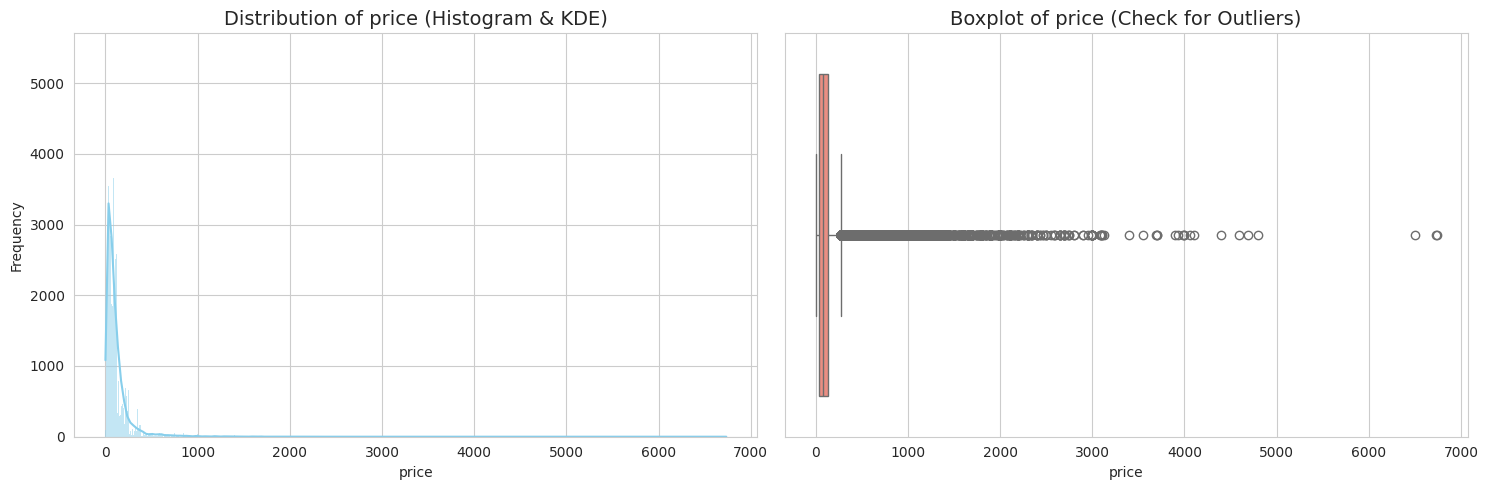

--- Analysis for price ---
Skewness: 7.92
Kurtosis: 120.82
Interpretasi: Distribusi bersifat Positive Skewed.
--------------------------------------------------


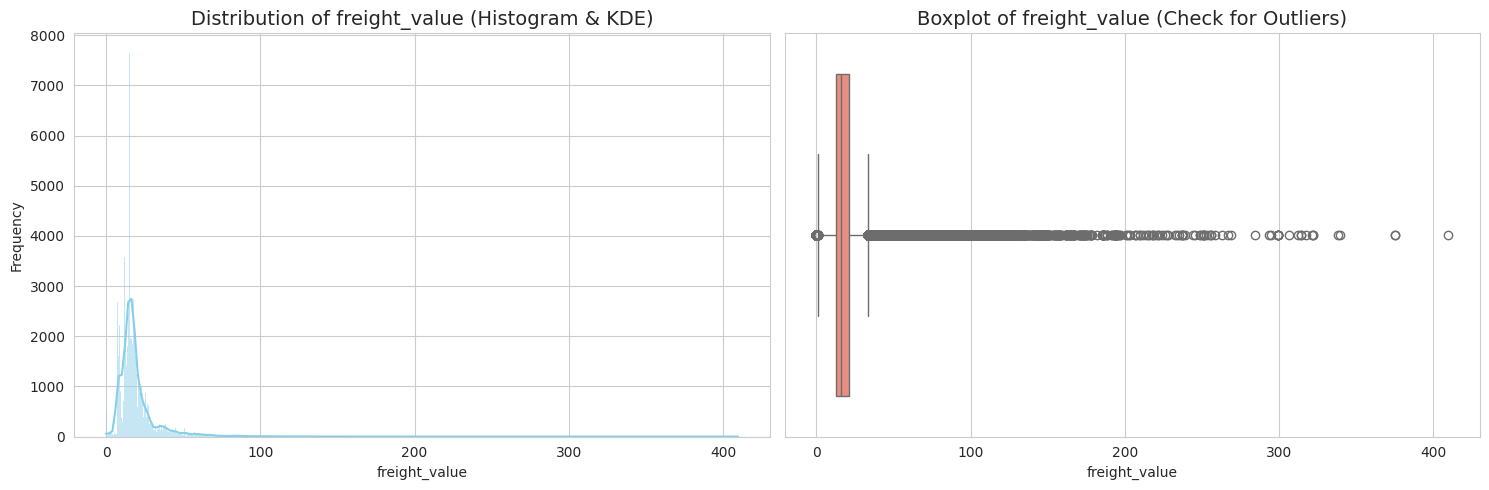

--- Analysis for freight_value ---
Skewness: 5.64
Kurtosis: 59.79
Interpretasi: Distribusi bersifat Positive Skewed.
--------------------------------------------------


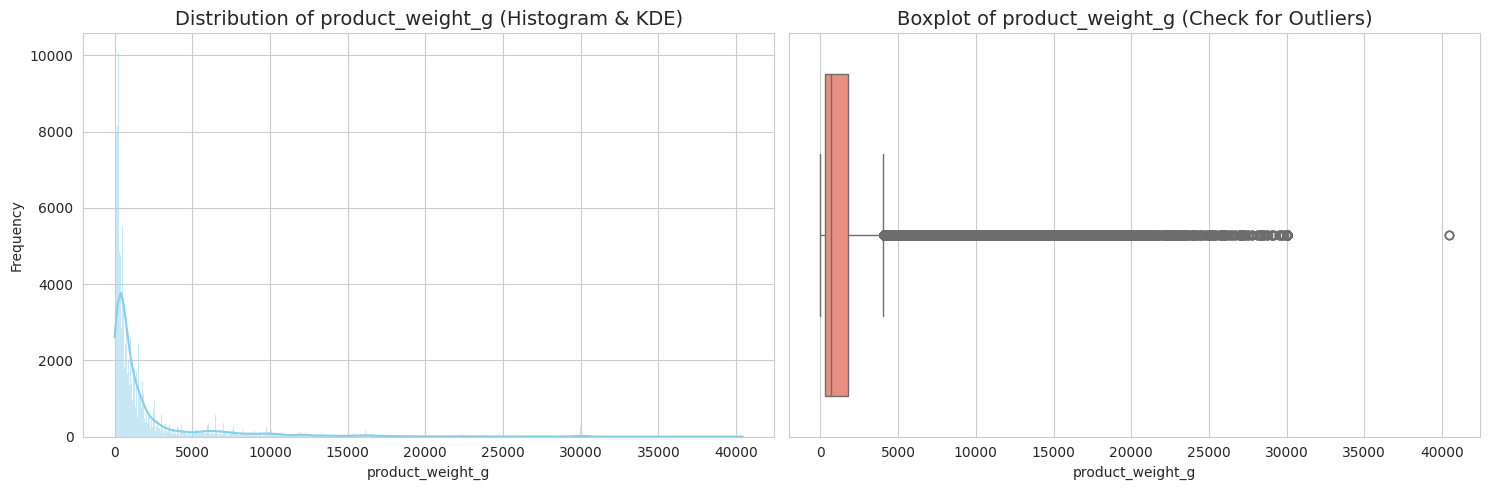

--- Analysis for product_weight_g ---
Skewness: 3.59
Kurtosis: 16.23
Interpretasi: Distribusi bersifat Positive Skewed.
--------------------------------------------------


In [208]:
print(order_items_df.describe())

cols_to_analyze = ['price', 'freight_value', 'product_weight_g']

for col in cols_to_analyze:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Visualisasi 1: Histogram + KDE
    sns.histplot(all_df[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution of {col} (Histogram & KDE)', fontsize=14)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Visualisasi 2: Boxplot
    sns.boxplot(x=all_df[col], ax=axes[1], color='salmon')
    axes[1].set_title(f'Boxplot of {col} (Check for Outliers)', fontsize=14)
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

    # Analisis Statistik: Skewness & Kurtosis
    col_skew = skew(all_df[col].dropna())
    col_kurt = kurtosis(all_df[col].dropna())

    print(f"--- Analysis for {col} ---")
    print(f"Skewness: {col_skew:.2f}")
    print(f"Kurtosis: {col_kurt:.2f}")

    if abs(col_skew) < 0.5:
        print("Interpretasi: Distribusi cenderung simetris (Normal).")
    else:
        print(f"Interpretasi: Distribusi bersifat {'Positive' if col_skew > 0 else 'Negative'} Skewed.")

    print("-" * 50)

**Insight:**
- Analisis Distribusi price: Distribusi harga memiliki nilai Skewness 7,92 dan Kurtosis 120,82, yang menunjukkan sifat Positive Skewed yang sangat ekstrem. Median berada di angka 74,99, jauh di bawah rata-rata (120,65). Terdapat outliers yang sangat jauh hingga mencapai 6.735,00.
- Analisis Boxplot price
  - Kotak (interquartile range) terlihat sangat "gepeng" dan menempel di sisi kiri (bawah), diikuti oleh garis panjang ke kanan yang penuh dengan titik-titik pencilan (outliers).
  - 50% data (IQR) berkumpul sangat padat di rentang harga yang sempit (sekitar 39.90 hingga 134.90).
  - Titik-titik di luar kumis kanan melewati 6.000
- Analisis Distribusi freight_value: Nilai ongkos kirim memiliki Skewness 5,64 dan Kurtosis 59,79. Rata-rata ongkir adalah 19,99, namun terdapat lonjakan biaya hingga 409,68. Jarak antara median (16,26).
- Analisis Boxplot freight_value
  - Kotak lebih terlihat proporsional dibanding harga, tapi tetap memiliki banyak titik outliers di sisi kanan.
  - Outliers yang mencapai 400+ adalah anomali.

- Analisis Distribusi product_weight_g
Berat produk memiliki Skewness 3,60 dan Kurtosis 16,26. Median berat produk hanya 700 gram, sedangkan rata-ratanya 2.093 gram. Platform ini didominasi oleh barang-barang ringan (di bawah 1 kg). Namun, keberadaan barang dengan berat hingga 40 kg menarik rata-rata ke atas.
- Analisis Boxplot product_weight_g:
  - Garis tengah (Median) di dalam kotak berada sangat jauh ke kiri. Kumis kanan sangat panjang.
  - Batas atas kotak (Q3) berada di angka 1.740 gram. Artinya, 75% barang di platform beratnya di bawah 1,7 kg.
  - Produk 40 kg adalah pencilan yang sangat ekstrem.


### Explore Multivariate

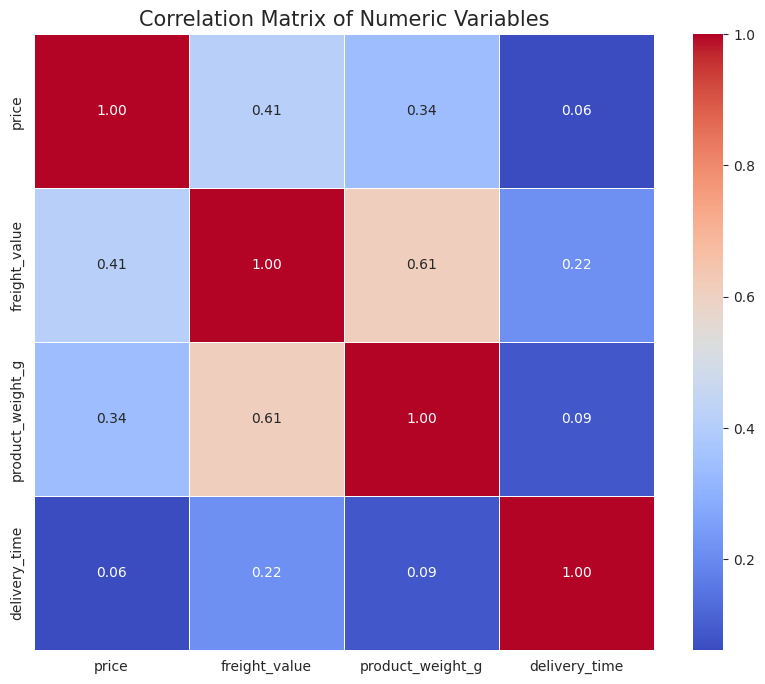

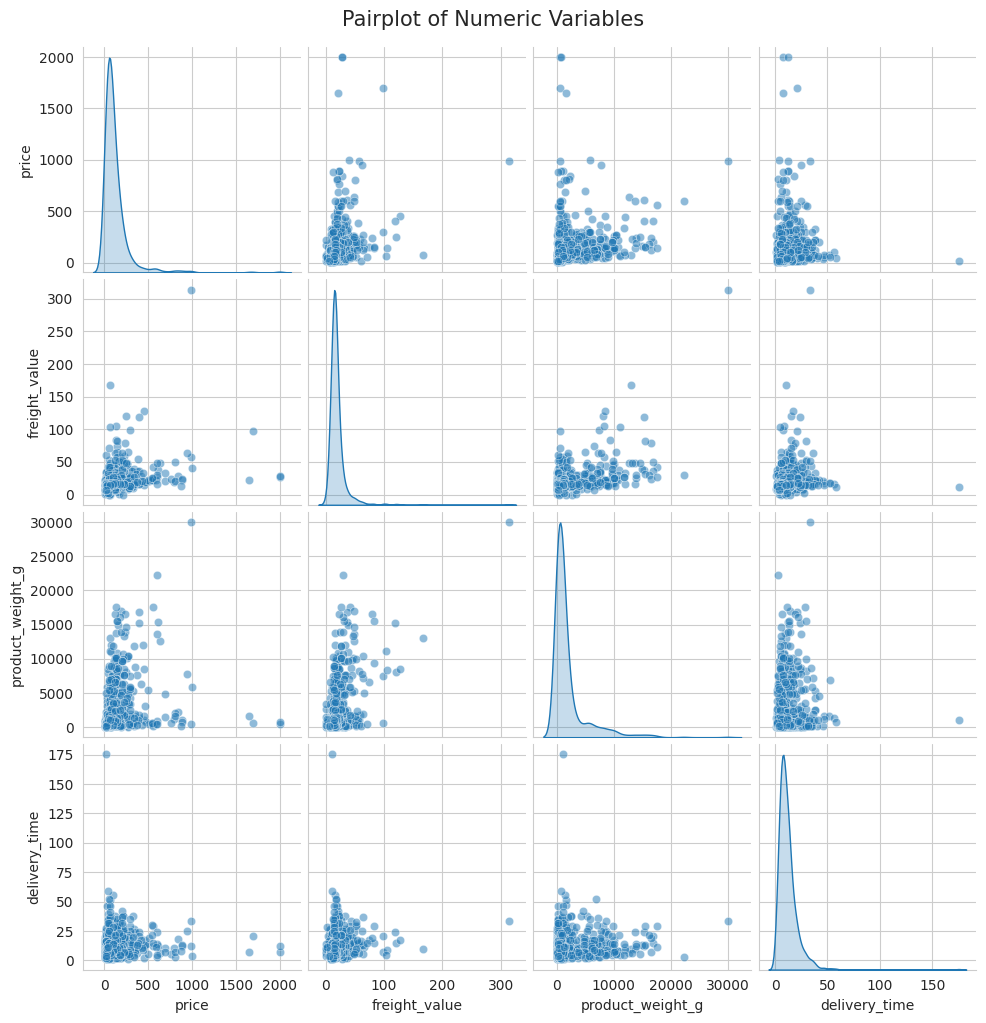

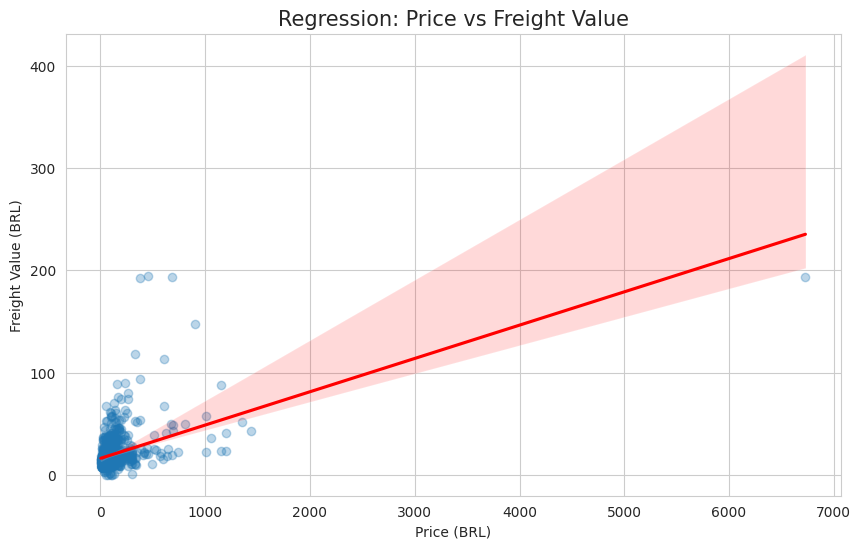

In [209]:
if 'delivery_time' not in all_df.columns:
    all_df['delivery_time'] = (all_df['order_delivered_customer_date'] - all_df['order_purchase_timestamp']).dt.days

numeric_cols = ['price', 'freight_value', 'product_weight_g', 'delivery_time']
corr_df = all_df[numeric_cols].dropna()

# Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = corr_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Variables", fontsize=15)
plt.show()

# Pairplot
sns.pairplot(corr_df.sample(min(1000, len(corr_df))), diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Pairplot of Numeric Variables", y=1.02, fontsize=15)
plt.show()

# Scatter Plot dengan Regression Line (Price vs Freight Value)
plt.figure(figsize=(10, 6))
sns.regplot(x='price', y='freight_value', data=corr_df.sample(min(1000, len(corr_df))),
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Regression: Price vs Freight Value", fontsize=15)
plt.xlabel("Price (BRL)")
plt.ylabel("Freight Value (BRL)")
plt.show()

- Matriks Korelasi (Heatmap)
  - Hubungan Terkuat (Strong Correlation): Korelasi tertinggi ditemukan antara product_weight_g dan freight_value sebesar 0.61. Ini menunjukkan hubungan positif yang kuat; semakin berat sebuah produk, maka biaya pengirimannya (ongkir) cenderung semakin mahal.
  - Hubungan Harga & Ongkir (Moderate Correlation): Variabel price dan freight_value memiliki korelasi moderat sebesar 0.41. Hal ini mengindikasikan bahwa produk dengan harga lebih tinggi seringkali memiliki biaya pengiriman yang lebih tinggi pula, kemungkinan disebabkan oleh dimensi produk yang lebih besar atau asuransi pengiriman tambahan.
  - Waktu Pengiriman dan Biaya (Weak Correlation): Variabel delivery_time memiliki korelasi yang sangat rendah dengan variabel lainnya (di bawah 0.25). Hal ini menunjukkan bahwa lama pengiriman lebih dipengaruhi oleh faktor eksternal seperti jarak atau performa kurir, daripada harga atau berat barang itu sendiri.
- Pairplot & Scatter Plot
  - Pairplot: Visualisasi ini mengonfirmasi bahwa sebagian besar variabel tidak memiliki hubungan linear sempurna, namun pola kepadatan data (KDE) menunjukkan konsentrasi transaksi yang tinggi pada kategori produk murah dan ringan.
  - Tren Regresi (Price vs Freight Value): Grafik Regression Plot menunjukkan garis tren berwarna merah yang mengarah ke atas (positif). Meskipun data cukup tersebar (scattered), tren ini mempertegas bahwa peningkatan harga barang diikuti dengan kenaikan biaya pengiriman secara rata-rata.

### Explore Numerical

--- Detailed Percentile Analysis ---
       price  freight_value  delivery_time
0.05   17.00          7.780       2.995324
0.10   23.80          8.730       4.142106
0.25   39.90         13.080       6.736262
0.50   74.99         16.260      10.184282
0.75  134.90         21.150      15.541097
0.90  229.80         34.041      22.921071
0.95  349.90         45.120      29.058967




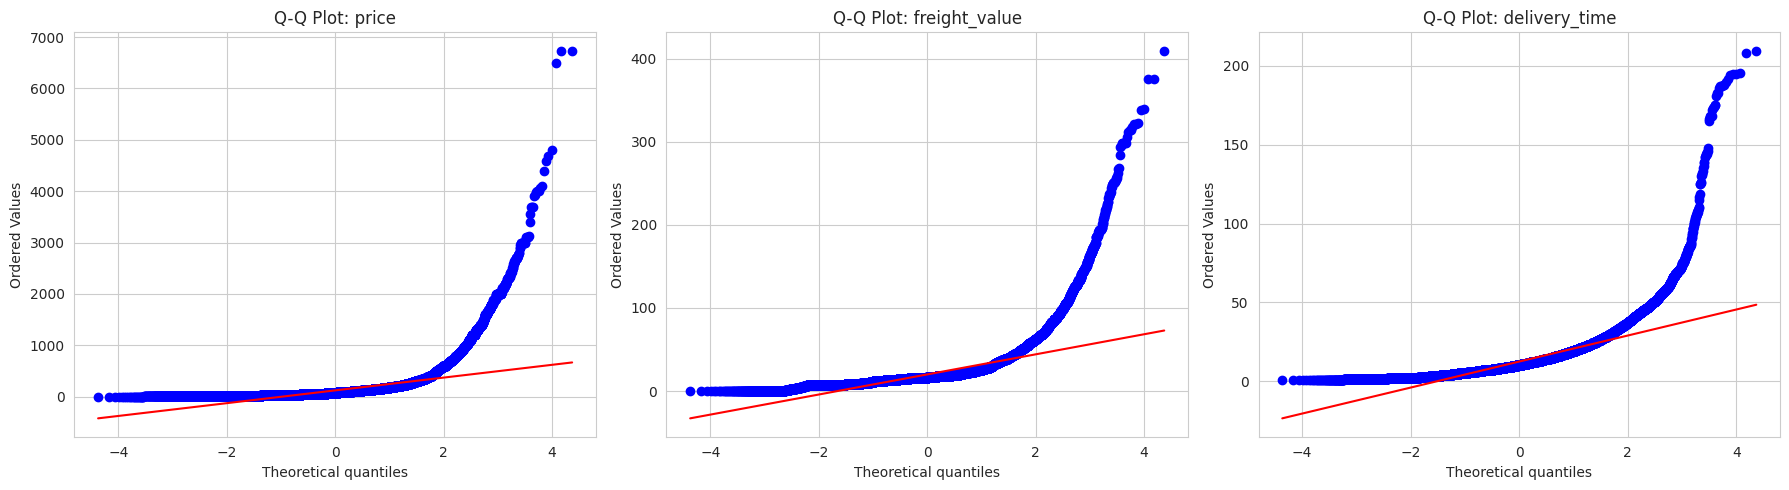

--- Variabilitas Harga per Kategori (Top 10 High Spread) ---
                                              mean         std            var
product_category_name_english                                                
computers                              1098.340542  668.513798  446910.698673
small_appliances_home_oven_and_coffee   624.285658  609.848752  371915.500124
home_appliances_2                       476.124958  544.416488  296389.312511
small_appliances                        280.778468  471.259273  222085.302823
musical_instruments                     281.616000  446.041029  198952.599830
art                                     115.802105  445.661765  198614.408747
fixed_telephony                         225.693182  420.831784  177099.390602
agro_industry_and_commerce              342.124858  419.429802  175921.358853
construction_tools_safety               208.992371  318.683621  101559.250389
costruction_tools_tools                 154.407282  264.404943   69909.973871


In [210]:
# 1. Detailed Percentile Analysis
cols_to_check = ['price', 'freight_value', 'delivery_time']
percentiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]

print("--- Detailed Percentile Analysis ---")
print(all_df[cols_to_check].quantile(percentiles))
print("\n")

# 2. Normality Testing (Q-Q Plots)
plt.figure(figsize=(18, 5))
for i, col in enumerate(cols_to_check):
    ax = plt.subplot(1, 3, i + 1)
    stats.probplot(all_df[col].dropna(), dist="norm", plot=plt)
    ax.set_title(f"Q-Q Plot: {col}")

plt.tight_layout()
plt.show()

# 3. Variance & Standard Deviation Analysis (Per Category)
category_spread = all_df.groupby('product_category_name_english')['price'].agg(['mean', 'std', 'var']).sort_values(by='std', ascending=False).head(10)

print("--- Variabilitas Harga per Kategori (Top 10 High Spread) ---")
print(category_spread)

**Insight:**
- Detailed Percentile Analysis
  - Price: Terdapat lonjakan drastis dari persentil 90 (229.80 BRL) ke persentil 95 (349.90 BRL). Hal ini menunjukkan bahwa meskipun mayoritas produk cukup terjangkau, terdapat segmen "High-End" yang nilainya jauh melampaui rata-rata.
  - Delivery Time: 90% pesanan sampai dalam waktu kurang dari 23 hari. Namun, pada persentil 95, waktunya naik menjadi 29 hari. Ini menunjukkan adanya long-tail pada keterlambatan pengiriman yang perlu mendapat perhatian operasional.
- Normality Testing (Q-Q Plot)
Ketiga grafik Q-Q Plot (price, freight_value, dan delivery_time) menunjukkan pola yang identik:
  - Titik-titik data (biru) menyimpang jauh dari garis merah (teoretis normal) pada sisi kanan atas (ujung kanan).Maka dapat disimpulkan bahwa Data tidak berdistribusi normal. Pola melengkung ke atas ini mengonfirmasi adanya distribusi Heavy-Tailed (ekor berat), yang berarti nilai-nilai ekstrem (outliers) muncul jauh lebih sering daripada yang diperkirakan pada distribusi normal.
- Variabilitas Harga per Kategori (Spread Analysis)
Tabel variabilitas menunjukkan kategori produk dengan tingkat penyebaran harga tertinggi:
  - Kategori computers memiliki Standar Deviasi (std) tertinggi (668.51) dan Variance (var) yang masif (446.910).Nilai Standar Deviasi yang besar (hampir mendekati nilai rata-rata/mean) menandakan adanya variabilitas harga yang sangat tinggi di dalam kategori tersebut. Contohnya, pada kategori Computers, terdapat barang murah (seperti aksesori) dan barang sangat mahal (seperti laptop/server), sehingga nilai mean saja tidak cukup untuk menggambarkan harga pasar kategori ini tanpa mempertimbangkan sebarannya.

### Explore Kategorikal

/tmp/ipykernel_5755/2810066863.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=all_df[all_df['product_category_name_english'].isin(top_categories)],


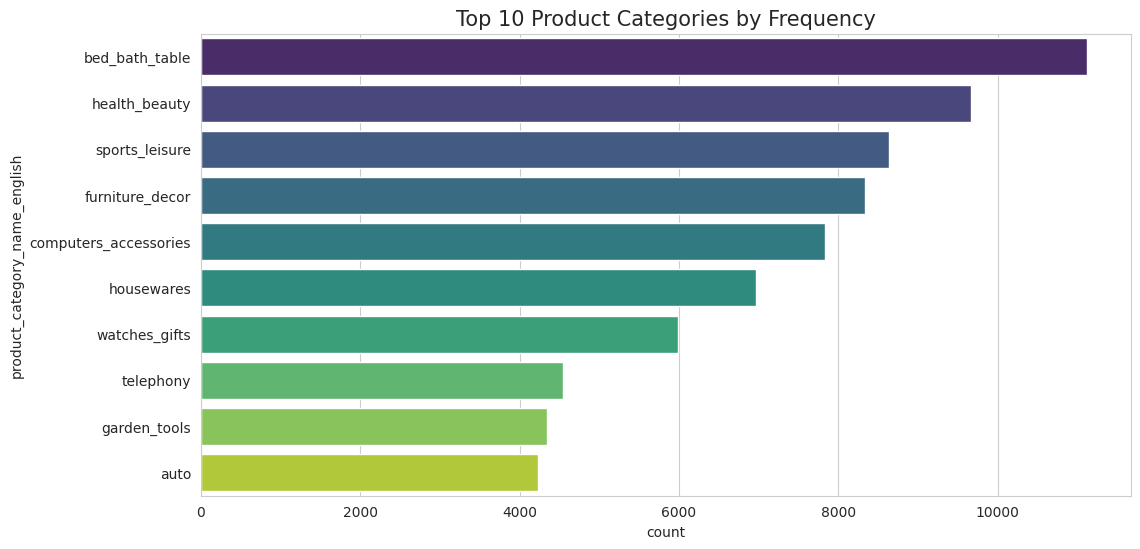

/tmp/ipykernel_5755/2810066863.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=all_df[all_df['product_category_name_english'].isin(top_5_cats)],


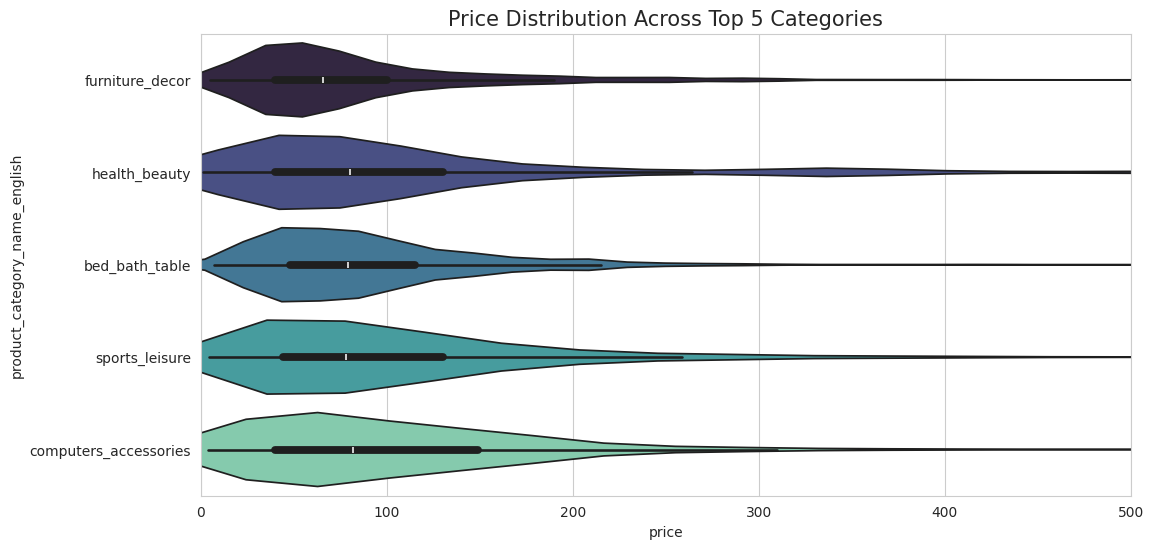

In [211]:
import scipy.stats as stats

# 1. Seaborn Countplot
plt.figure(figsize=(12, 6))
top_categories = all_df['product_category_name_english'].value_counts().head(10).index
sns.countplot(data=all_df[all_df['product_category_name_english'].isin(top_categories)],
              y='product_category_name_english',
              order=top_categories,
              palette='viridis')
plt.title("Top 10 Product Categories by Frequency", fontsize=15)
plt.show()

# 2. Violin Plot (Distribution Across Categories)
plt.figure(figsize=(12, 6))
# Melihat distribusi harga di 5 kategori teratas
top_5_cats = all_df['product_category_name_english'].value_counts().head(5).index
sns.violinplot(data=all_df[all_df['product_category_name_english'].isin(top_5_cats)],
               x='price', y='product_category_name_english', palette='mako')
plt.title("Price Distribution Across Top 5 Categories", fontsize=15)
plt.xlim(0, 500)
plt.show()

**Insight**
- Dominasi Kategori Produk (Countplot)
Berdasarkan grafik Top 10 Product Categories by Frequency
  - Kategori bed_bath_table memimpin jauh di atas kategori lainnya dengan lebih dari 11.000 transaksi. Sangat kuat di kategori kebutuhan rumah tangga (furniture_decor, housewares) dan perawatan diri (health_beauty).
- Distribusi Harga pada Kategori Teratas (Violin Plot)
Berdasarkan grafik Price Distribution Across Top 5 Categories:
  - Mayoritas kategori memiliki konsentrasi harga di bawah 100 BRL (terlihat dari bagian "perut" violin yang lebar di sisi kiri).
  - Kategori computers_accessories menunjukkan distribusi harga yang lebih merata hingga ke angka yang lebih tinggi dibandingkan kategori lainnya.
  - Bentuk violin yang memanjang ke kanan (ekor panjang) pada semua kategori mengonfirmasi adanya outliers atau produk premium di setiap kategori, namun jumlahnya jauh lebih sedikit dibandingkan produk mass-market (pasar massal) yang dimana barang-barang yang diproduksi dalam jumlah sangat besar dan ditujukan untuk sebanyak mungkin orang, tanpa memandang latar belakang spesifik atau niche tertentu.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa pendapatan (revenue) dari berbagai kategori produk selama periode tahun 2018, dan kategori mana yang memberikan kontribusi paling signifikan?

/tmp/ipykernel_5755/2510834207.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


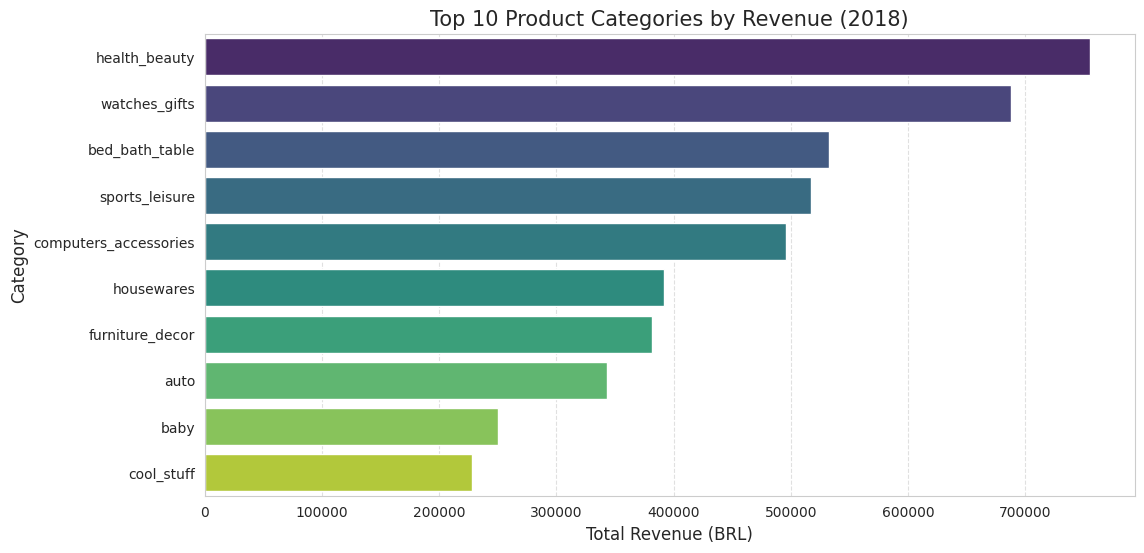

In [212]:
# 1. Menyiapkan data: Top 10 Kategori berdasarkan Revenue di 2018
top_categories_2018 = category_revenue.head(10)

# 2. Membuat Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    x="revenue",
    y="product_category_name_english",
    data=top_categories_2018,
    palette="viridis"
)

# 3. Menambahkan Detail Label
plt.title("Top 10 Product Categories by Revenue (2018)", fontsize=15)
plt.xlabel("Total Revenue (BRL)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Menampilkan grafik
plt.show()

### Pertanyaan 2: Bagaimana segmentasi profil pelanggan berdasarkan perilaku belanja menggunakan metode analisis RFM pada periode tahun 2018 untuk merancang strategi pemasaran yang lebih personal?

,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0004bd2a26a76fe21f786e4fbd80607f,146,1,154.00
3,00050ab1314c0e55a6ca13cf7181fecf,132,1,27.99
4,00053a61a98854899e70ed204dd4bafe,183,1,382.00


/tmp/ipykernel_5755/2758712448.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_5755/2758712448.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipykernel_5755/2758712448.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_valu

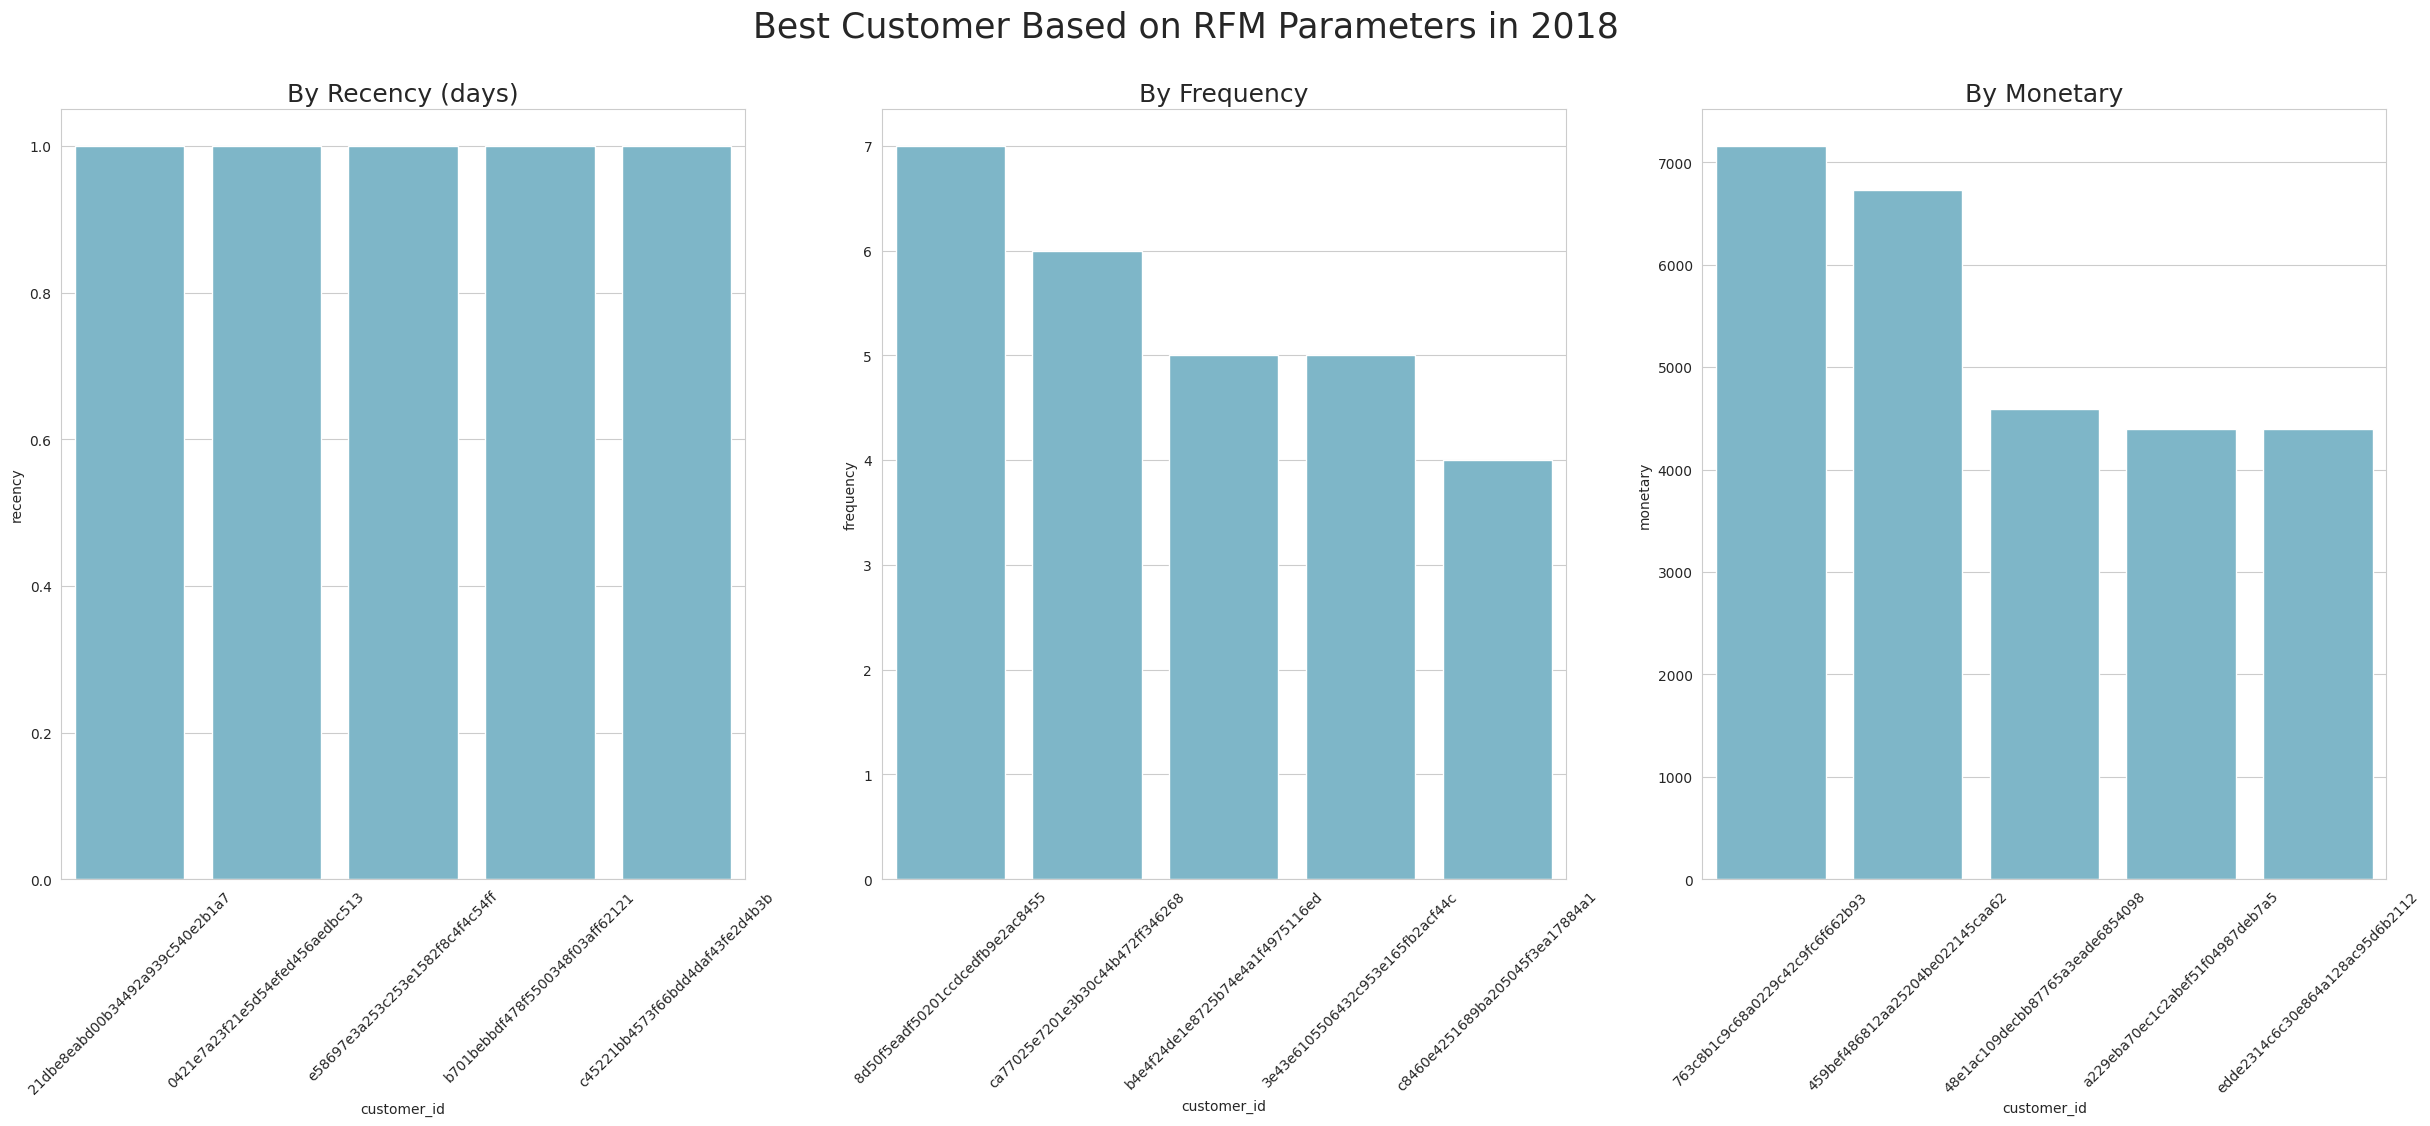

In [213]:
main_df_2018 = all_df[all_df['order_purchase_timestamp'].dt.year == 2018]

snapshot_date = main_df_2018['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = main_df_2018.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']
display(rfm_df.head())

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Plot Recency
sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', rotation=45)

# Plot Frequency
sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', rotation=45)

# Plot Monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters in 2018", fontsize=25)
plt.show()

### Pertanyaan 3: Bagaimana tren performa penjualan perusahaan dari bulan ke bulan selama tahun 2018?

/tmp/ipykernel_5755/1012904067.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_2018 = all_df_2018.resample(rule='M', on='order_purchase_timestamp').agg({


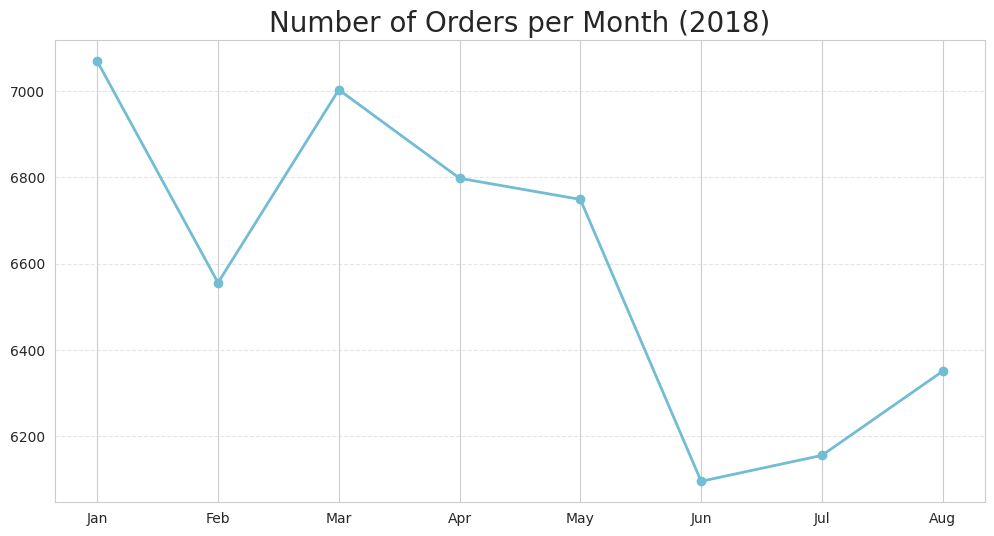

In [214]:
# 1. Menyiapkan data tren bulanan 2018
monthly_orders_2018 = all_df_2018.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

# Mengubah format bulan agar enak dibaca (Jan, Feb, dst)
monthly_orders_2018['order_month'] = monthly_orders_2018['order_purchase_timestamp'].dt.strftime('%b')

# 2. Membuat Visualisasi Line Chart
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_orders_2018['order_month'],
    monthly_orders_2018['order_id'],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Number of Orders per Month (2018)", loc="center", fontsize=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Analisis Lanjutan (Opsional)

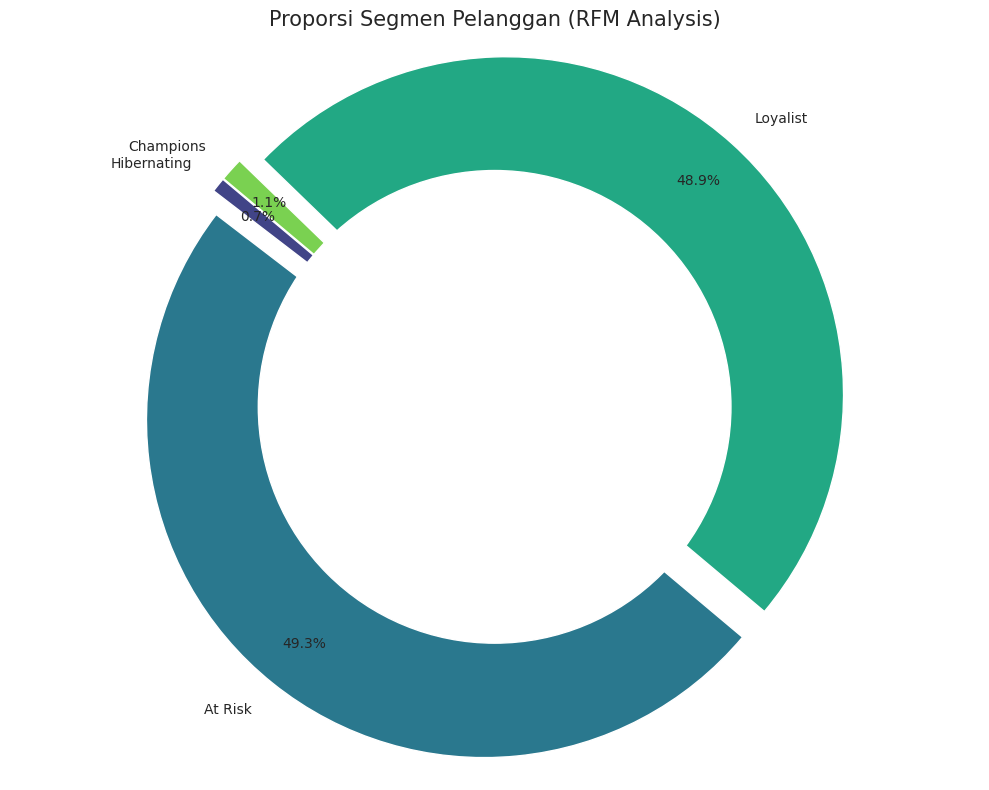

In [215]:
rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

rfm_df['r_rank_norm'] = (rfm_df['r_rank']/rfm_df['r_rank'].max())*100
rfm_df['f_rank_norm'] = (rfm_df['f_rank']/rfm_df['f_rank'].max())*100
rfm_df['m_rank_norm'] = (rfm_df['m_rank']/rfm_df['m_rank'].max())*100

rfm_df['rfm_score'] = rfm_df[['r_rank_norm', 'f_rank_norm', 'm_rank_norm']].mean(axis=1)

rfm_df.drop(columns=['r_rank', 'f_rank', 'm_rank'], inplace=True)

rfm_df['customer_segment'] = pd.cut(rfm_df['rfm_score'],
                                    bins=[0, 20, 50, 80, 100],
                                    labels=['Hibernating', 'At Risk', 'Loyalist', 'Champions'],
                                    include_lowest=True)

segment_counts = rfm_df['customer_segment'].value_counts().sort_index()

plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(segment_counts))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    explode=[0.05] * len(segment_counts)
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Proporsi Segmen Pelanggan (RFM Analysis)", fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- Conclusion Pertanyaan 1:

  - Kategori Health & Beauty menjadi kontributor pendapatan terbesar sepanjang tahun 2018 dengan total revenue mencapai 755754.49 (BRL) dan jumlah order sebanyak 5306 . Posisi kedua ada pada Watches/Gifts (687577.20 BRL) dengan jumlah order sebanyak 3416. Kemudian posisi ketiga adalah Bed Bath Table (532358.85 BRL) dengan jumlah order sebanyak 4844. Hal ini menunjukkan bahwa tidak semua kategori dengan volume tinggi menghasilkan revenue tinggi.
  - Di sisi lain, terdapat kategori dengan performa terendah seperti cool_stuff yang hanya menyumbang 227743.70 BRL dengan jumlah order 1391 dan baby sebesar 250615.79 BRL dengan jumlah order 1627.
  - Dominasi kategori Health & Beauty menunjukkan adanya permintaan pasar yang sangat stabil dan masif pada produk kecantikan dan kesehatan.
  - **Insight**:
    - health_beauty = high demand + high revenue
    - watches_gifts = low volume tapi high value per transaksi
    - Artinya, performa bisnis tidak hanya ditentukan oleh jumlah order, tapi juga nilai transaksi per order.
- Recommendation Pertanyaan 1
  - Optimasi kategori high revenue (health_beauty) dengan buat bundling produk (contoh: skincare set).
  - Berikan diskon pembelian kedua (repeat order incentive) karena kategori ini sudah terbukti punya demand tinggi
  - Maksimalkan kategori high-value (watches_gifts) dengan fokus pada strategi upselling & premium positioning. Gunakan flash sale terbatas limited edition campaign, karena pelanggan di kategori ini cenderung tidak sensitif harga.
  - Tingkatkan performa kategori lain (low contribution). Identifikasi kategori dengan revenue rendah lalu buat cross-selling dengan kategori top. Misal: beli skincare, kemudian direkomendasikan aksesoris.

- Conclusion Pertanyaan 2:
Berdasarkan hasil analisis RFM tahun 2018, maka didapatkan insight sebagai berikut:
  - Recency: Nilai recency pada data berada di 112 - 183 hari sejak transaksi terakhir. Terdapat pelanggan yang masih relatif “recent” (< 120 hari), namun juga banyak yang sudah cukup lama tidak bertransaksi >150 hari. Sehingga sudah mulai terlihat indikasi penurunan engagement pada bagian customer.
  - Frequency: Berdasarkan data mayoritas pelanggan hanya melakukan 1 transaksi.Perilaku pelanggan didominasi oleh one-time buyer sehingga repeat order masih sangat rendah. Masalah utama ada pada retensi pelanggan.
  - Monetary: Nilai monetary pada data minimumnya ad apada 18.90 BRL dan maksimumnya 382.00 BRL. Secara keseluruhan Rata-ratanya adalah 140.64 BRL dan maksimumnya 6.929.31 BRL (lihat pada Statistik Deskriptif order_items_df). Terdapat gap besar antara low spender vs high spender.
  - Kemudian dari hasil analisis tersebut, dibagilah menjadi 4 segmen dengan proporsi At Risk: 49.3%, Loyalist: 48,9%, Hibernating: 0,7%, Champions: 1.1 %. Dominasi segmen At Risk menunjukkan bahwa banyak pelanggan yang mulai tidak aktif, sementara segmen Loyalist yang hampir sama besar mengindikasikan adanya peluang untuk meningkatkan pelanggan menjadi lebih loyal dan bernilai tinggi. Namun, jumlah Champions yang sangat kecil (1,1%) menunjukkan bahwa pelanggan dengan kontribusi tinggi terhadap revenue masih terbatas. Di sisi lain, segmen hibernating merupakan pelanggan yang sudah lama tidak aktif, memiliki frekuensi transaksi rendah, serta nilai transaksi yang kecil. Meskipun jumlahnya relatif sedikit, segmen ini menunjukkan adanya pelanggan yang sudah hampir sepenuhnya tidak terlibat dengan bisnis.
- Recommendation Pertanyaan 2:
  - Banyak pelanggan sudah lama tidak transaksi (recency tinggi hingga 183 hari)
    - Kirim voucher personal (bukan promo umum) dengan batas waktu. contoh: diskon 20% berlaku 3 hari
    - Gunakan email / push notification berbasis histori pembelian “Produk yang pernah kamu beli sekarang diskon”. Terapkan win-back campaign otomatis setelah X hari tidak transaksi (misal 30 - 60 hari)
  - Frekuensi masih rendah (mayoritas hanya 1 transaksi), tapi masih aktif
    - Berikan insentif repeat order. contoh: diskon pembelian ke-2 atau ke-3
    - Terapkan bundling produk. contoh: paket skincare / paket hemat
    - Gunakan upselling: rekomendasi produk dengan harga lebih tinggi
  - Jumlah kecil tapi kontribusi revenue besar
    - Buat VIP / loyalty program eksklusif speerti reward point atau cashback khusus. Berikan: early access promo, produk eksklusif / limited edition
  - Customer sudah lama tidak aktif dan nilai rendah
    - Gunakan flash sale umum atau broadcast promo sederhana

- Conclution Pertanyaan 3:
  - Berdasarkan hasil visualisasi jumlah order per bulan tahun 2018, terlihat bahwa performa penjualan mengalami fluktuasi sepanjang periode Januari hingga Agustus.
    - Pada Januari jumlah order 7.069 order, kemudian sedikit menurun pada Februari menjadi sekitar 6.556 order.
    - Pada Maret, jumlah order kembali meningkat hingga sekitar 7.003 order, sebelum mengalami tren penurunan bertahap pada April (6.798 order) dan Mei (6.749 order).
    - Penurunan paling signifikan terjadi pada Juni, di mana jumlah order turun drastis menjadi sekitar 6.096 order, yang merupakan titik terendah selama periode tersebut.
    - Setelah itu, terjadi sedikit pemulihan pada Juli (6.156 order) dan Agustus (6.351 order), meskipun belum kembali ke level awal tahun.
    - Hasil visualisasi di atas juga diperkuat dengan hasil EDA explore all_data bagian monthly_order
  - Terdapat tren penurunan dari awal hingga pertengahan tahun, terutama penurunan tajam dari Mei ke Juni.Bulan Januari dan Maret menunjukkan performa terbaik, yang mengindikasikan adanya kemungkinan pengaruh: momentum awal tahun atau campaign/promosi tertentu. Penurunan drastis pada Juni (6.096 order) mengindikasikan adanya: penurunan demand atau kurangnya aktivitas promosi pada periode tersebut.

- Recommendation Pertanyaan 3:
  - Bulan Januari dan Maret memiliki jumlah order tertinggi. Maka lakukan Identifikasi campaign yang berjalan pada bulan tersebut (promo, diskon, event). Kemudian terapkan kembali campaign serupa di bulan lain terutama sebelum periode penurunan (Mei-Juni).
  - Terjadi penurunan signifikan dari Mei (6.749 order) ke Juni (6.096 order). Jalankan mid-year sale campaign (promo besar di Juni), flash sale mingguan selama periode tersebut. Kemudian berikan diskon terbatas waktu (urgency-based promotion)
  - Fluktuasi cukup tinggi antar bulan. Maka buat campaign rutin bulanan, seperti payday sale (akhir bulan), promo tanggal kembar (11.11, 12.12 style) dan terapkan kalender promosi tahunan (marketing calendar)

In [216]:
all_df.to_csv("main_data.csv", index=False)